In [ ]:
from google.colab import files
uploaded = files.upload()

Saving penguins.csv to penguins (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/penguins.csv')

In [ ]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
df.isnull().sum()

,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,9


In [ ]:
df.fillna(0,inplace=True)

In [ ]:
df['sex'] = df['sex'].map({'male':1,'female':0})

In [ ]:
df['sex'] = df['sex'].fillna('unknown')

df_processed = pd.get_dummies(df, columns=['sex'], drop_first=True)

display(df_processed.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,0.0,0.0,0.0,0.0
4,36.7,19.3,193.0,3450.0


In [ ]:
from sklearn.preprocessing import StandardScaler

features = df_processed.columns

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed)

df_scaled = pd.DataFrame(df_scaled, columns=features)

display(df_scaled.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,-0.715821,0.698756,-0.122227,-0.496900
1,-0.653120,0.147736,-0.102991,-0.438760
2,-0.527718,0.402053,-0.068366,-1.078308
3,-6.844844,-7.227462,-0.818570,-4.857456
4,-1.092027,0.953073,-0.076061,-0.845745


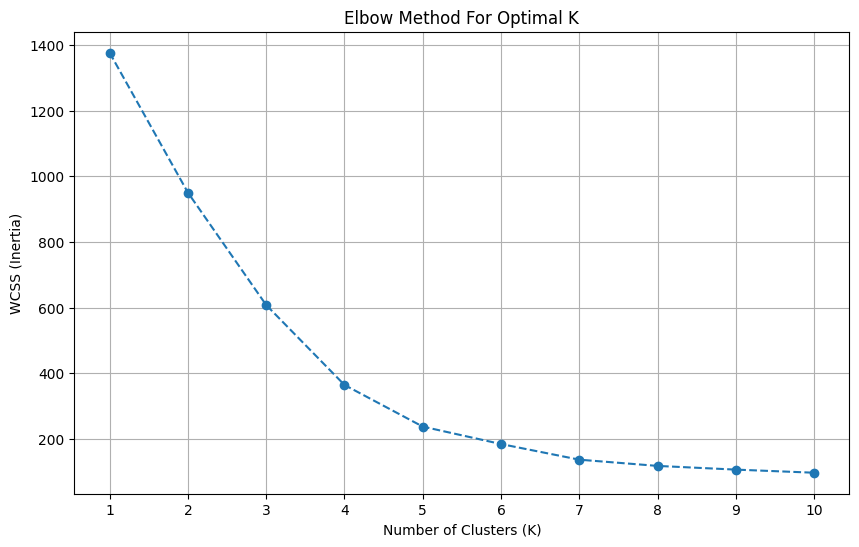

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_processed['cluster'] = clusters

display(df_processed.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,cluster
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,0.0,0.0,0.0,0.0,0
4,36.7,19.3,193.0,3450.0,0


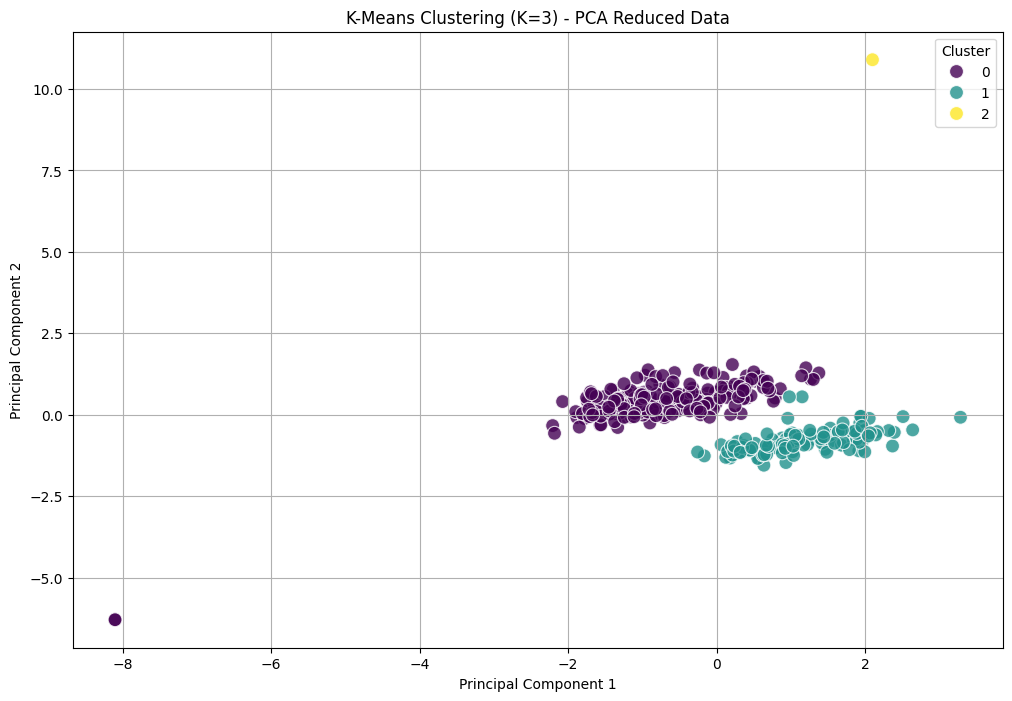

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=df_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', s=100, alpha=0.8)
plt.title(f'K-Means Clustering (K={optimal_k}) - PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()